# MACD EMA Trend Strategy - Train/Test Split Optimization

This notebook demonstrates how to:
1. Load ETF data from the framework's bundle
2. Build MACD and EMA features
3. Split data into training and testing sets
4. Run grid search optimization on training data
5. Evaluate best parameters on test data

Based on strategy from [ZiadFrancis/MACD_EMA_Trend](https://github.com/ZiadFrancis/MACD_EMA_Trend)

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path

import sys
sys.path.insert(0, '/app')
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
!pip install pandas_ta


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
!pip install backtesting


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np

from core.data_org import BUNDLE_DIR
from strat.s_macd_ema import (
    build_features,
    MACDEMA_SwingOrATR,
    split_and_optimize,
    run_backtest,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

/usr/local/lib/python3.12/site-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

## 2. Configuration

Configure the ETF symbol and optimization parameters.

In [5]:
ETF_SYMBOL = "QQQ"  # Options: QQQ, SPY, TLT, GLD, VWO

SPLIT_RATIO = 0.5       # Fraction of data for training
EMA_LEN = 200           # EMA period (configurable)

RR_GRID = [1.5, 2.0, 2.5]           # Risk-reward ratios to test
SW_WINDOW_GRID = [3, 5, 7]          # Swing window sizes to test

## 3. Helper Functions

In [6]:
def convert_framework_columns_to_ohlcv(df, prefix=None):
    """
    Convert framework column format to standard OHLCV format.
    
    Framework uses: S_close_f32, S_open_f32, etc.
    Strategy expects: Close, Open, High, Low, Volume
    """
    ohlcv_df = pd.DataFrame(index=df.index)
    
    if prefix and f"{prefix}_S_close_f32" in df.columns:
        ohlcv_df["Close"] = df[f"{prefix}_S_close_f32"]
        ohlcv_df["Open"] = df[f"{prefix}_S_open_f32"]
        ohlcv_df["High"] = df[f"{prefix}_S_high_f32"]
        ohlcv_df["Low"] = df[f"{prefix}_S_low_f32"]
        ohlcv_df["Volume"] = df[f"{prefix}_S_volume_f64"]
    elif "S_close_f32" in df.columns:
        ohlcv_df["Close"] = df["S_close_f32"]
        ohlcv_df["Open"] = df["S_open_f32"]
        ohlcv_df["High"] = df["S_high_f32"]
        ohlcv_df["Low"] = df["S_low_f32"]
        ohlcv_df["Volume"] = df["S_volume_f64"]
    else:
        for col_type, target in [
            ("close", "Close"),
            ("open", "Open"),
            ("high", "High"),
            ("low", "Low"),
            ("volume", "Volume"),
        ]:
            matching_cols = [c for c in df.columns if f"_S_{col_type}_" in c.lower()]
            if matching_cols:
                ohlcv_df[target] = df[matching_cols[0]]
    
    # Convert time column to datetime index
    if "i_minute_i" in df.columns:
        base = pd.Timestamp("2000-01-01")
        ohlcv_df.index = base + pd.to_timedelta(df["i_minute_i"].astype(int), unit='m')
    
    return ohlcv_df.dropna()

## 4. Load Data

In [7]:
bundle_file = BUNDLE_DIR / "candle_1hour" / f"{ETF_SYMBOL}_features.parquet"

if not bundle_file.exists():
    raise FileNotFoundError(
        f"Bundle not found: {bundle_file}\n"
        f"Please run: python scripts/features/compute_etf_bundle.py"
    )

print(f"Loading {ETF_SYMBOL} from: {bundle_file}")
df_raw = pd.read_parquet(bundle_file)
print(f"Raw data shape: {df_raw.shape}")

ohlcv_df = convert_framework_columns_to_ohlcv(df_raw)
print(f"OHLCV data shape: {ohlcv_df.shape}")
print(f"Date range: {ohlcv_df.index[0]} to {ohlcv_df.index[-1]}")
ohlcv_df.head()

Loading QQQ from: /app/data/bundle/candle_1hour/QQQ_features.parquet
Raw data shape: (92274, 123)
OHLCV data shape: (92274, 5)
Date range: 2000-01-03 09:00:00 to 2026-02-26 19:00:00


,Close,Open,High,Low,Volume
i_minute_i,,,,,
2000-01-03 09:00:00,96.789284,99.871735,99.871735,96.691994,8984264.0
2000-01-03 10:00:00,95.199417,96.821793,97.957367,94.485634,9491568.0
2000-01-03 11:00:00,96.464897,95.231804,96.724388,94.226036,8086721.0
2000-01-03 12:00:00,96.189041,96.432396,96.562195,95.653709,2276071.0
2000-01-03 13:00:00,96.951591,96.253944,97.340874,95.978088,3187450.0


## 5. Build Features

In [8]:
df_features = build_features(ohlcv_df, ema_len=EMA_LEN)
print(f"Features shape: {df_features.shape}")

n_signals = (df_features['pre_signal'] != 0).sum()
n_long = (df_features['pre_signal'] == 1).sum()
n_short = (df_features['pre_signal'] == -1).sum()

print(f"\nSignal Summary:")
print(f"  Total signals: {n_signals}")
print(f"  Long signals:  {n_long}")
print(f"  Short signals: {n_short}")

df_features[['Close', 'EMA200', 'MACD_12_26_9', 'MACDs_12_26_9', 'pre_signal']].tail(10)

Features shape: (92075, 13)

Signal Summary:
  Total signals: 592
  Long signals:  408
  Short signals: 184


,Close,EMA200,MACD_12_26_9,MACDs_12_26_9,pre_signal
i_minute_i,,,,,
2026-02-26 10:00:00,715.306213,716.991392,1.146322,2.357814,0
2026-02-26 11:00:00,714.263794,716.964251,0.363073,1.958865,0
2026-02-26 12:00:00,713.451111,716.929295,-0.319551,1.503182,0
2026-02-26 13:00:00,715.335693,716.913438,-0.700392,1.062467,0
2026-02-26 14:00:00,717.067139,716.914967,-0.852668,0.679440,0
2026-02-26 15:00:00,717.620728,716.921990,-0.918095,0.359933,0
2026-02-26 16:00:00,716.077759,716.913590,-1.081979,0.071551,0
2026-02-26 17:00:00,715.253235,716.897069,-1.263822,-0.195524,0
2026-02-26 18:00:00,715.064819,716.878837,-1.406919,-0.437803,0


## 6. Run Split Optimization

In [9]:
print("="*60)
print("Running Grid Search Optimization")
print("="*60)
print(f"\nConfiguration:")
print(f"  Split ratio:   {SPLIT_RATIO:.0%} train / {1-SPLIT_RATIO:.0%} test")
print(f"  EMA period:    {EMA_LEN}")
print(f"  RR grid:       {RR_GRID}")
print(f"  SW grid:       {SW_WINDOW_GRID}")
print()

results = split_and_optimize(
    ohlcv_df,
    strategy_class=MACDEMA_SwingOrATR,
    split_ratio=SPLIT_RATIO,
    ema_len=EMA_LEN,
    rr_grid=RR_GRID,
    sw_window_grid=SW_WINDOW_GRID,
)

Running Grid Search Optimization

Configuration:
  Split ratio:   50% train / 50% test
  EMA period:    200
  RR grid:       [1.5, 2.0, 2.5]
  SW grid:       [3, 5, 7]

Data split: 46137 train / 46137 test bars
Train: 2000-01-03 09:00:00 to 2014-08-11 05:00:00
Test: 2014-08-11 06:00:00 to 2026-02-26 19:00:00

Optimizing on training data...


Backtest.optimize:   0%|          | 0/9 [00:00<?, ?it/s]

Backtest.run:   0%|          | 0/45937 [00:00<?, ?bar/s]


Best parameters from training:
  rr: 2.5
  sw_window: 7
  atr_mult: 2.0

Evaluating on test data with best parameters...


Backtest.run:   0%|          | 0/45937 [00:00<?, ?bar/s]


RESULTS SUMMARY
Train Return [%]:    65.20
Train Sharpe:        0.23
Train # Trades:      188
Train Win Rate [%]:  33.51
Test Return [%]:     -12.32
Test Sharpe:         -0.15
Test # Trades:       237
Test Win Rate [%]:   36.29
Test Max DD [%]:     -25.31


## 7. Results Summary

In [10]:
train_stats = results['train_stats']
test_stats = results['test_stats']
best_params = results['best_params']

print("\n" + "="*60)
print("BEST PARAMETERS")
print("="*60)
for key, val in best_params.items():
    print(f"  {key}: {val}")

print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)
print(f"Return [%]:       {train_stats['Return [%]']:.2f}")
print(f"Sharpe Ratio:     {train_stats['Sharpe Ratio']:.2f}")
print(f"Max DD [%]:       {train_stats['Max. Drawdown [%]']:.2f}")
print(f"# Trades:         {train_stats['# Trades']}")
print(f"Win Rate [%]:     {train_stats['Win Rate [%]']:.2f}")

print("\n" + "="*60)
print("TEST RESULTS (Out-of-Sample)")
print("="*60)
print(f"Return [%]:       {test_stats['Return [%]']:.2f}")
print(f"Sharpe Ratio:     {test_stats['Sharpe Ratio']:.2f}")
print(f"Max DD [%]:       {test_stats['Max. Drawdown [%]']:.2f}")
print(f"# Trades:         {test_stats['# Trades']}")
print(f"Win Rate [%]:     {test_stats['Win Rate [%]']:.2f}")

print("\n" + "="*60)
print("TRAIN VS TEST COMPARISON")
print("="*60)
print(f"Return Diff:      {test_stats['Return [%]'] - train_stats['Return [%]']:.2f}%")
print(f"Sharpe Diff:      {test_stats['Sharpe Ratio'] - train_stats['Sharpe Ratio']:.2f}")


BEST PARAMETERS
  rr: 2.5
  sw_window: 7
  atr_mult: 2.0

TRAINING RESULTS
Return [%]:       65.20
Sharpe Ratio:     0.23
Max DD [%]:       -44.91
# Trades:         188
Win Rate [%]:     33.51

TEST RESULTS (Out-of-Sample)
Return [%]:       -12.32
Sharpe Ratio:     -0.15
Max DD [%]:       -25.31
# Trades:         237
Win Rate [%]:     36.29

TRAIN VS TEST COMPARISON
Return Diff:      -77.51%
Sharpe Diff:      -0.38


## 8. Optimization Heatmap

In [11]:
heatmap = results['heatmap']

print("\nHeatmap (Return [%]):")
if isinstance(heatmap, pd.Series):
    heatmap_unstacked = heatmap.unstack()
    print(heatmap_unstacked.round(2))
else:
    print(heatmap)


Heatmap (Return [%]):
sw_window      3      5      7
rr                            
1.5       -18.26 -16.12  -9.99
2.0        14.62  15.24  17.42
2.5        43.34  38.88  65.20


## 9. Visualize Heatmap

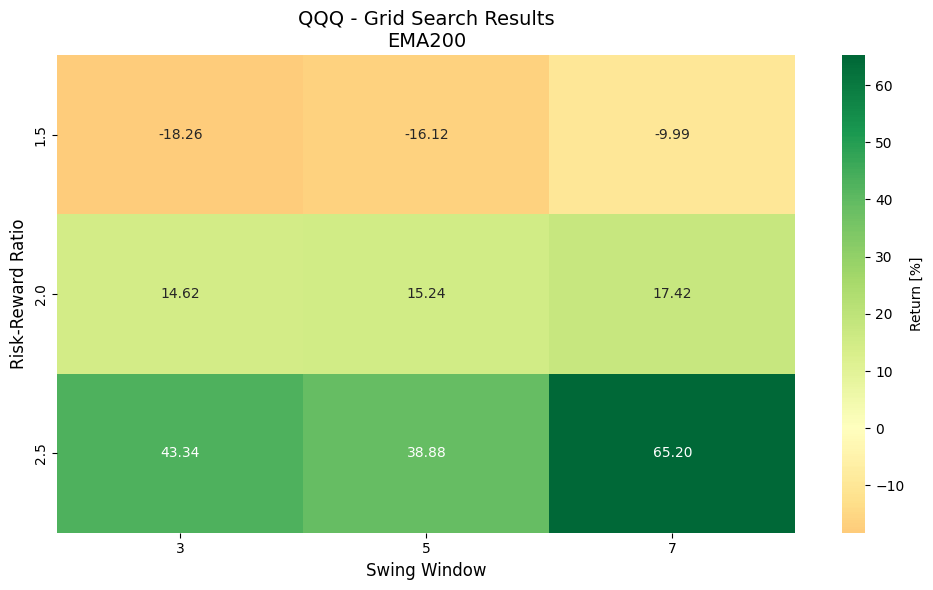

In [17]:
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    if isinstance(heatmap, pd.Series):
        heatmap_df = heatmap.unstack()
        
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.heatmap(
            heatmap_df,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            center=0,
            cbar_kws={'label': 'Return [%]'},
            ax=ax
        )
        ax.set_title(f'{ETF_SYMBOL} - Grid Search Results\nEMA{EMA_LEN}', fontsize=14)
        ax.set_xlabel('Swing Window', fontsize=12)
        ax.set_ylabel('Risk-Reward Ratio', fontsize=12)
        plt.tight_layout()
        plt.show()
except ImportError:
    print("Matplotlib/Seaborn not available for visualization")

## 10. Save Results

In [ ]:
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

results_summary = pd.DataFrame([{
    'ETF': ETF_SYMBOL,
    'EMA_Len': EMA_LEN,
    'Split_Ratio': SPLIT_RATIO,
    'Best_RR': best_params.get('rr'),
    'Best_SW': best_params.get('sw_window'),
    'Train_Return': train_stats['Return [%]'],
    'Train_Sharpe': train_stats['Sharpe Ratio'],
    'Train_WinRate': train_stats['Win Rate [%]'],
    'Test_Return': test_stats['Return [%]'],
    'Test_Sharpe': test_stats['Sharpe Ratio'],
    'Test_WinRate': test_stats['Win Rate [%]'],
    'Test_MaxDD': test_stats['Max. Drawdown [%]'],
    'Test_Trades': test_stats['# Trades'],
}])

output_file = output_dir / f"{ETF_SYMBOL}_split_optimize_results.csv"
results_summary.to_csv(output_file, index=False)
print(f"Results saved to: {output_file}")

results_summary

## 11. Conclusion

This notebook demonstrated:

1. **Data Loading**: Loaded real ETF data from the framework's bundle
2. **Feature Engineering**: Built MACD and EMA features with configurable parameters
3. **Train/Test Split**: Divided data into training (50%) and testing (50%) sets
4. **Grid Search**: Optimized risk-reward ratio and swing window parameters
5. **Out-of-Sample Testing**: Evaluated best parameters on unseen test data

### Next Steps

- Try different ETFs (SPY, TLT, GLD, VWO)
- Experiment with different EMA periods (100, 150, 200)
- Adjust the split ratio (0.6, 0.7, 0.8)
- Test other strategy variants (MACDEMA_ATRTrail, MACDEMA_SwingWindow)